In [6]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
#from idlpy import *

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

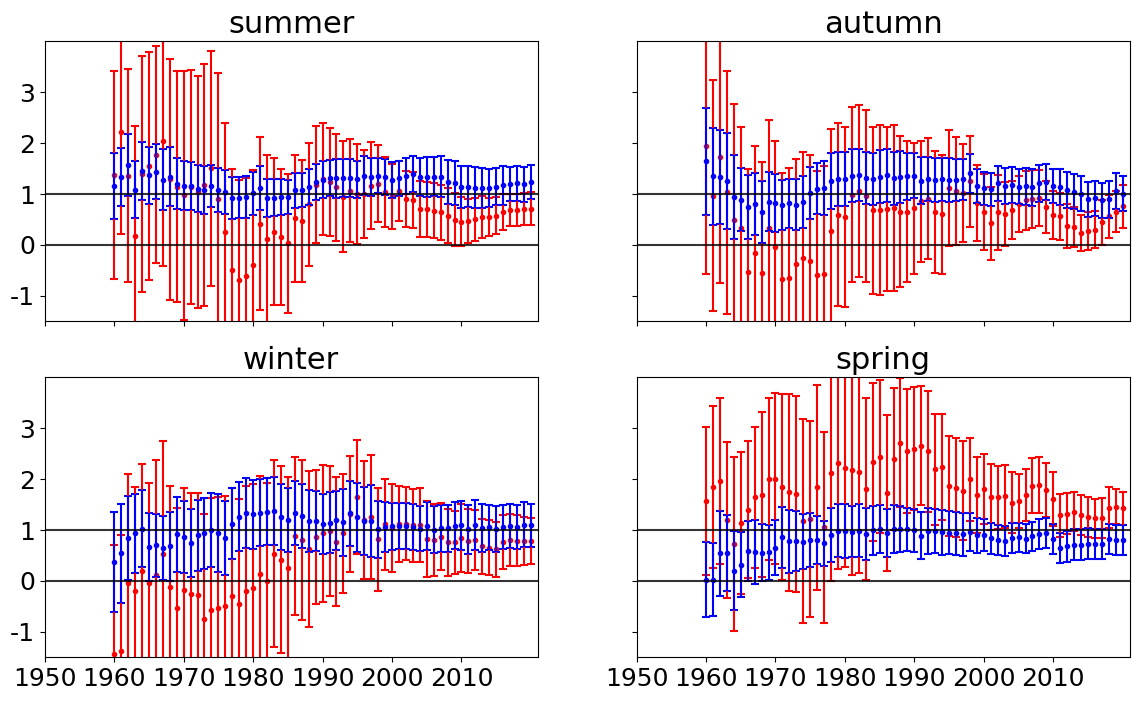

In [7]:
plot_saved_result()

In [4]:
def plot_saved_result():

    df = pd.read_csv('/home/queenle/hydro_attribution/result_files/d4PDF_TA_obs_scanning_endyears.csv')

    fig,axs = plt.subplots(2,2,figsize=(14,8),sharex=True,sharey=True)
    axs = axs.flatten()

    for i,s in enumerate(['summer','autumn','winter','spring']):

        ax = axs[i]

        season_df = df.loc[df['season']==s]

        ax.scatter(season_df['end_year'],season_df['ant_best'],color='red',marker='.',label='ANT')
        ax.scatter(season_df['end_year'],season_df['ant_upper'],color='red',marker='_')
        ax.scatter(season_df['end_year'],season_df['ant_lower'],color='red',marker='_')
        ax.vlines(season_df['end_year'],season_df['ant_lower'],season_df['ant_upper'],color='red')

        ax.scatter(season_df['end_year'],season_df['nat_best'],color='blue',marker='.',label='NAT')
        ax.scatter(season_df['end_year'],season_df['nat_upper'],color='blue',marker='_')
        ax.scatter(season_df['end_year'],season_df['nat_lower'],color='blue',marker='_')
        ax.vlines(season_df['end_year'],season_df['nat_lower'],season_df['nat_upper'],color='blue')

        ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
        ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
        
        font['size'] = 18
        
        ax.set_ylim(-1.5,4)
        ax.set_yticks([-1,0,1,2,3])
        ax.set_yticklabels(['-1','0','1','2','3'],fontdict=font)

        ax.set_xlim(1960,2021)
        ax.set_xticks([1950+10*i for i in range(7)])
        ax.set_xticklabels([str(1950+10*i) for i in range(7)],fontdict=font)

        font['size'] = 22

        ax.set_title(s,fontdict=font)
        
    #plt.savefig('hydro_attribution/d4PDF/TA_OF_scanning_start_years.png',dpi=300)


In [60]:
[1950+10*i for i in range(7)]

[1950, 1960, 1970, 1980, 1990, 2000, 2010]

In [11]:
'''
MAIN function for performing optimal fingerprinting
'''



start = 1951

df_dict = {'start_year':[],'end_year':[],'season':[],'truncation':[],'ant_best':[],'ant_lower':[],'ant_upper':[],'nat_best':[],'nat_lower':[],'nat_upper':[]}

for end in [1960 + i for i in range(61)]:
    
    print(str(end))
    
    for i,season in enumerate(['summer','autumn','winter','spring']):

        #print(season)
        
        IDL.retall

        data_obs,all_ens_mean,noise_all,nat_ens_mean,noise_nat = get_all_data(season,start,end)

        data_scen = np.array([all_ens_mean,nat_ens_mean])
        data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

        #print('got arrays')

        trunc = 40

        IDL.data_obs = data_obs
        IDL.data_scen = data_scen
        IDL.data_noise_1 = data_noise_1
        IDL.data_noise_2 = data_noise_2
        IDL.trunc = trunc
        IDL.beta_est = []

        #print('running gendetec')
        IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est,  \
                data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc")

        beta_est = IDL.beta_est
        
        df_dict['ant_best'].append(beta_est[0][0])
        df_dict['ant_lower'].append(beta_est[1][0])
        df_dict['ant_upper'].append(beta_est[2][0])
        
        df_dict['nat_best'].append(beta_est[0][1])
        df_dict['nat_lower'].append(beta_est[1][1])
        df_dict['nat_upper'].append(beta_est[2][1])
        
        df_dict['start_year'].append(start)
        df_dict['end_year'].append(end)
        df_dict['truncation'].append(trunc)
        df_dict['season'].append(season)

    
df = pd.DataFrame.from_dict(df_dict)

df.to_csv('hydro_attribution/result_files/d4PDF_TA_obs_scanning_endyears.csv')


1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020


In [28]:
print(all_ens_mean.shape)
print(nat_ens_mean.shape)
print(data_obs.shape)
print(data_scen.shape)
print(data_noise_1.shape)
print(data_noise_2.shape)

(1187,)
(1187,)
(1203,)
(2, 1187)
(100, 1187)
(100, 1187)


In [5]:
def get_all_data(season, start, end):
    
    #print('getting obs')
    data_obs,missing_indices = get_obs_data(season,start,end)
    
    #print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(missing_indices,'HPB',season,start,end)
    
    #print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(missing_indices,'HPB_NAT',season,start,end)

    return(data_obs,all_ens_mean,noise_all,nat_ens_mean,noise_nat)

In [10]:
def get_obs_data(season,start,end):
    
    obs_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/temperature/temp_obs_'+season+'_gaussian.csv')
    obs_df = obs_df.set_index('date')
    obs_df = obs_df[str(start):str(end+1)]
    
    obs_array = obs_df.values.flatten()

    # find indices of nan values
    missing_indices = np.argwhere(np.isnan(obs_array))
    
    # remove nan values
    obs_array = np.delete(obs_array,missing_indices)
    
    return(obs_array,missing_indices)

def get_noise(missing_indices,scen,season,mean_array,start,end):
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
        mem_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/TA/seasonal/station_resolution/TA_d4PDF_'+scen+'_m'+number+'_gaussian_'+season+'_1951-2021.csv')
        mem_df = mem_df.set_index('time').drop('Unnamed: 0',axis=1)
        mem_df = mem_df[str(start):str(end+1)]
        mem_array = mem_df.values.flatten()
                
        # remove elements where observations were missing
        mem_array = np.delete(mem_array,missing_indices)
        
        diff_array = mem_array - mean_array
        
        noise.append(diff_array)
        
    return(noise)

def get_mean_and_noise(missing_indices,scen,season,start,end):
    
    mean_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/TA/seasonal/station_resolution/TA_d4PDF_'+scen+'_ensMean_gaussian_'+season+'_1951-2021.csv')
    mean_df = mean_df.set_index('time')
    mean_df = mean_df[str(start):str(end+1)]
    mean_array = mean_df.values.flatten()
    
    # remove elements where observations were missing
    mean_array = np.delete(mean_array,missing_indices)
        
    noise = get_noise(missing_indices,scen,season,mean_array,start,end)
    
    return((mean_array, np.array(noise)))
